In [ ]:
#All relevant imports for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
from scipy import stats

# **Does climate affect football match results?**

Sample project showcasing the expactations of the course project.

## Hypothesis/analysis goal (Ask)



> *Clearly state the data science hypothesis / the analytical goal you pursue in your project. From your description, it should be clear which question you address, what type of analysis is needed, and what quality metric is targeted.*



As worldwide football tournaments occur in various locations across the globe that present very different climatic conditions, an interesting question is if and how climate may affect team performance. Such descriptive analysis may support team management and coaches to improve team performance under conditions expected in future tournaments. In this context, we will explore the possible correlation between different climate conditions during matches and match outcomes. We emphasize that climate is different from weather conditions - the latter can substantially vary locally and over the course of a day whereas we understand climate here as a seasonal phenomenon that varies across larger regions.

## Data source identification and exploration (Prepare)





>*Make a brief requirements analysis for the data and data sources that you require to reach your goal.*





**Requirement analysis.** To tackle the problem, we need to have data about football matches that include when and where the match took place and what the result was. This data needs to be aligned with historical weather data at these times and locations. For accurate analysis, it is desirable to have sufficient data on matches for all different climatic conditions, requiring a broad coverage of geographies. It is sufficient to have one summary entry per match (no single events in matches) because the prediction aims at the final score. Climatic conditions vary seasonally so we do not need the weather at fine granularity (during the match time), day or even month may be enough.




> *List the sources you will report on for Deliverable 1 and link them to where you found them. In selecting which datasets you want to report on for exploration, take note of the following: (1) The subsequent data preparation and analysis should rely on at least 3 datasets; (2) the discussion concerning exploration needs to feature arguments for why datasets were selected and why others were not. No generated data should be used.*




**List of considered sources.** In the following, we outline several sources we considered and explored and justify the final source selection (marked with an *), in particular based on concepts discussed in class.

*   **Football match data**
  * [Global Football Results (DS1) - Match_Results.csv*](https://www.kaggle.com/datasets/muhammadehsan02/global-football-results-18722024?select=Match_Results.csv)
  *[ Individual tournament data for world cup (DS2)](https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup?select=matches_1930_2022.csv)
   
*   **Historical weather data**
  * [Historical daily weather data for capitals (DS3)](https://www.kaggle.com/datasets/balabaskar/historical-weather-data-of-all-country-capitals?select=daily_weather_data.csv)
  * [The Weather Dataset (DS4)*](https://www.kaggle.com/datasets/guillemservera/global-daily-climate-data?select=daily_weather.parquet)
  * [Weather API (DS5)*](https://openweathermap.org/api)


>*For further processing, the data first needs to be loaded. As sample_data is flushed regularly, you may mount a personal Google Drive to read data from there while working on your project. However, your deliverables must include code to read in data from the temporary sample_data folder, where we will upload the data referenced above for evaluation. Therefore, make sure the provided link / information refers to a specific file.*

### Guideline: Dataset exploration discussion



> We acknowledge that each dataset requires different exploration steps to come to the conclusion whether or not to use it. Therefore, no detailed guideline can be given, but we recommend incorporating the following sections:
*   Brief description of downloaded data and reflection on how well it matches requirements or how it is amenable to match the requirements.
*   Profiling steps that should include a short description, the code to execute these, and an interpretation and critical discussion of the results with respect to the suitability of the dataset for addressing the analytical task.
* Discussion of the quality of the data relating to aspects to be considered during data preparation and analysis. It should refer to at least two different quality criteria per explored dataset, one beign assessed positively and one assessed as problematic.
* Concluding paragraph that summarizes (non-)suitability and important points to take note of if the dataset is selected to be used.  






### DS1: Football Kaggle dataset exploration

**Description**. The kaggle dataset, downlaoded on 20/09/2024, contains match date, location data, and score, offering relevant information for our analysis. More precisely, it includes the city and country, which are at an appropriate level of granularity to be combined with meaningful climate data for our analysis. The same holds for the date of matches. The following code imports the data into a DataFrame and displays the first few rows, thereby giving an idea of the stored data.

In [ ]:
#Get table data from a the csv file about Match_Results, the file from the
#Kaggle repository we use

# Read in the csv file into a DataFrame
df = pd.read_csv('sample_data/Match_Results.csv')

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df)


             date    home_team away_team  home_score  away_score  \
0      1872-11-30     Scotland   England           0           0   
1      1873-03-08      England  Scotland           4           2   
2      1874-03-07     Scotland   England           2           1   
3      1875-03-06      England  Scotland           2           2   
4      1876-03-04     Scotland   England           3           0   
...           ...          ...       ...         ...         ...   
47394  2024-07-10  Netherlands   England           1           2   
47395  2024-07-10      Uruguay  Colombia           0           1   
47396  2024-07-13       Canada   Uruguay           2           2   
47397  2024-07-14        Spain   England           2           1   
47398  2024-07-14    Argentina  Colombia           1           0   

         tournament           city        country  neutral  
0          Friendly        Glasgow       Scotland    False  
1          Friendly         London        England    False  


Looking at this sample data, we see that the date is stored in yyyy-mm-dd format, which needs to be taken into account when combined with other datasets, which may have different format. Teams appear to be at country level, a more detailed analysis is advisable to see if only national or also club matches are present in the dataset. In terms of the geographical location, the city is given, which has sufficient granularity for our analysis. Similarly, the time granularity is sufficient as well to identify relevant climate data for a particular data. For our analytics tasks, we need to ensure that we sufficiently cover match locations exhibiting a variety of climates, e.g., beyond the UK.

**Exploring the teams covered in the dataset**



> *As per the project guide, you are allowed to use generative AI to support you. This exemplar embeds one example of the required paper trail of GAI use. You are required to report every use analogously in a separate file that is to be handed in with Deliverable 3.*



Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  List the distinct teams in the dataset
Generated output |see comment in DS1 - code cell 2
Impacted notebook cell | DS1 - code cell 2

In [ ]:
# prompt: List the distinct teams in the dataset

### ORIGINAL GAI OUTPUT
### Assuming 'df' is the DataFrame loaded from 'Match_Results.csv' as shown in the provided code.
### distinct_teams = df['home_team'].unique()
### distinct_teams

# Get the unique teams from both the 'home_team' and 'away_team' columns
unique_teams = pd.concat([df['home_team'], df['away_team']]).unique()

# Print the list of unique teams
print(unique_teams)


['Scotland' 'England' 'Wales' 'Northern Ireland' 'United States' 'Uruguay'
 'Austria' 'Hungary' 'Argentina' 'Belgium' 'France' 'Guernsey' 'Jersey'
 'Netherlands' 'Czechoslovakia' 'Alderney' 'Switzerland' 'Sweden'
 'Germany' 'Italy' 'Chile' 'Norway' 'Finland' 'Luxembourg' 'Russia'
 'Denmark' 'Catalonia' 'Philippines' 'Basque Country' 'China PR' 'Brazil'
 'Japan' 'Paraguay' 'Canada' 'Estonia' 'Costa Rica' 'Guatemala' 'Spain'
 'Brittany' 'Poland' 'Yugoslavia' 'New Zealand' 'Romania' 'Latvia'
 'Galicia' 'Portugal' 'Andalusia' 'Australia' 'Lithuania' 'Turkey'
 'Central Spain' 'Mexico' 'Aruba' 'Egypt' 'Republic of Ireland' 'Haiti'
 'Bulgaria' 'Jamaica' 'Kenya' 'Bolivia' 'Peru' 'Honduras' 'Guyana'
 'Uganda' 'Belarus' 'El Salvador' 'Barbados' 'Trinidad and Tobago'
 'Greece' 'Cuba' 'Curaçao' 'Dominica' 'Silesia' 'Guadeloupe' 'Israel'
 'Suriname' 'French Guiana' 'Panama' 'Colombia' 'Venezuela' 'Ecuador'
 'Saint Kitts and Nevis' 'Slovakia' 'Manchukuo' 'Croatia' 'Nicaragua'
 'Afghanistan' 'India' 

From the above program, we gather that teams limit to national teams. We assume that this is fine for the application but are aware that limiting to these highly professional teams, our prediction may be affected as the players may be less affected by weather conditions (as they perform well no matter the weather).

**Exploration of covered countries**

In [ ]:
# prompt: SELECT country, COUNT(*) FROM table GROUP BY country ORDER BY COUNT(*) DESC

# Assuming 'df' is your DataFrame with the match data
country_counts = df.groupby('country')['country'].count().sort_values(ascending=False)
print(country_counts)


country
United States          1399
France                  889
Malaysia                813
England                 745
Qatar                   701
                       ... 
Portuguese Guinea         1
Mali Federation           1
Micronesia                1
Bohemia and Moravia       1
Belgian Congo             1
Name: country, Length: 270, dtype: int64


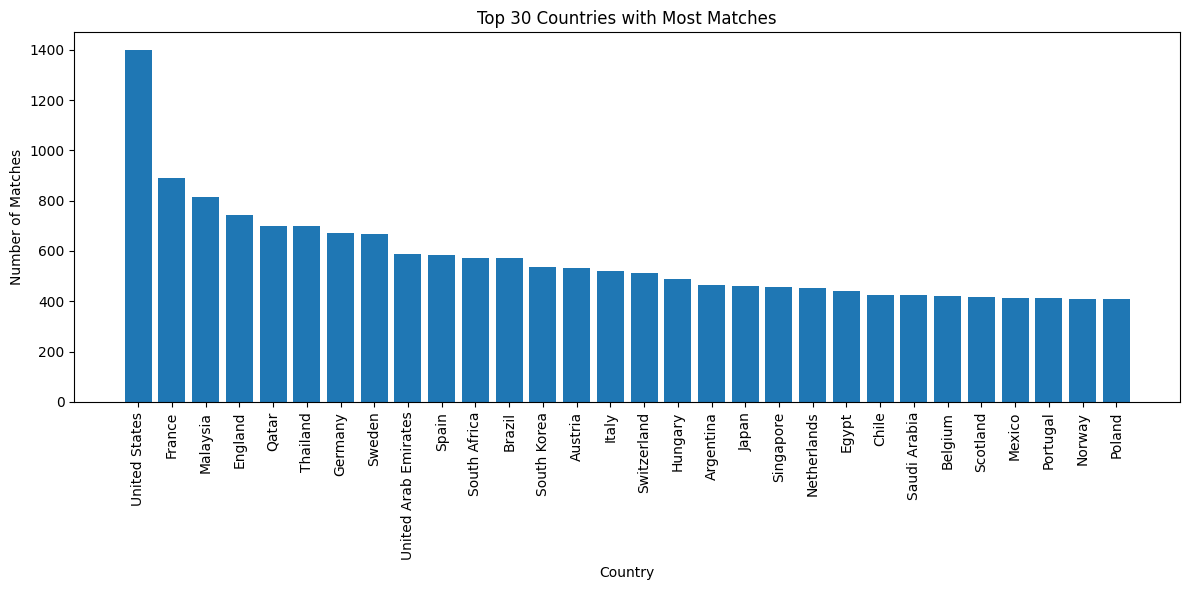

In [ ]:
# Select the top 30 countries in terms of number of appearance in the data,
# according to country_counts
top_30_countries = country_counts.head(30)

# Create a histogram
plt.figure(figsize=(12, 6))
plt.bar(top_30_countries.index, top_30_countries.values)
plt.xlabel('Country')
plt.ylabel('Number of Matches')
plt.title('Top 30 Countries with Most Matches')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


Overall, we observe that most countries are covered, but the frequency of matches in countries highly varies. This may introduce some bias during analysis if the training data is dominated by one climate region. In the plot showing the top-30 countries in terms of number of matches, we observe that countries from different climatic zones are included (US cover more than just one, then central European like France and Germany are covered, Qatar and UAE with dry desert climate, Malaysia and Singapore with tropical climate), so different weather conditions should be present in the data (but to different degree, which may lead to bias as discussed before). As part of data preparation, we will take special care in creating a balanced dataset to avoid bias.

**Exploring covered tournaments**

In [ ]:
# List all the distinct tournament values

# Determine distinc tournaments
distinct_tournaments = df['tournament'].unique()

# Print the list of distinct tournaments
print(distinct_tournaments)


['Friendly' 'British Home Championship' 'Évence Coppée Trophy'
 'Muratti Vase' 'Copa Lipton' 'Copa Newton' 'Copa Premio Honor Argentino'
 'Copa Premio Honor Uruguayo' 'Far Eastern Championship Games' 'Copa Roca'
 'Copa América' 'Peace Cup' 'Open International Championship'
 'Copa Chevallier Boutell' 'Olympic Games' 'Nordic Championship'
 'Central European International Cup' 'Baltic Cup' 'Balkan Cup'
 'Central American and Caribbean Games' 'FIFA World Cup' 'Copa Rio Branco'
 'FIFA World Cup qualification' 'Bolivarian Games' 'CCCF Championship'
 'NAFC Championship' 'Copa Oswaldo Cruz' 'Asian Games'
 'Pan American Championship' 'Copa del Pacífico' "Copa Bernardo O'Higgins"
 'AFC Asian Cup qualification' 'Atlantic Cup' 'AFC Asian Cup'
 'African Cup of Nations' 'Copa Paz del Chaco' 'Merdeka Tournament'
 'UEFA Euro qualification' 'Southeast Asian Peninsular Games'
 'African Friendship Games' 'UEFA Euro' 'Windward Islands Tournament'
 'African Cup of Nations qualification' 'Vietnam Independen

A wide range of worldwide tournaments is covered, the dataset thereby is representative of a large variety of national teams playing at various levels across the world. This may alleviate the previously identified problem of focusing the analysis on national teams only.

**Data quality considerations**

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:


*   In terms of completeness, the dataset satisfies our requirement for the task at hand as it is quite comprehensive in the coverage of mational team matches worldwide, i.e., presents match data in sufficient breadth, depth, and scope.
*   The interpretability of the dataset is high, given that it limits to few essential attributes with clear semantics. This makes misinterpretation and misuse highly during analysis highly unlikely.
* While the reputation of Kaggle is good in the data science community, the reputation of the dataset remains unclear. No authors are listed on the Kaggle web page and the provenance remains vague (e.g.,sources not named, no mention of quality check of automatically scraped data).

Despite the moderate reputation, the dataset ideally fits our data requirements so we eventually opted to use it. We are however aware that potential errors in the data can affect the accuracy of the trained model.


**Conclusion for Kaggle football dataset**

In light of the above data exploration, we consider the dataset suited for our analysis with the following caveats, which we will keep in mind during data preparation and analysis:

*   Locations may exhibit an overrepresentation of some climate zones, which may need to be countered by appropriate sampling of the training data.
*   Due to unclear source reputation, our model may be based on erroneous data. Cross-validating the data using authoritative sources or studying how transferrable the model is to other input data are possible options to mitigate this problem, but are not further considered within the scope of this mini-project.




### DS2: World Cup Dataset from Kaggle

**Description.** We downladed the CSV file from Kaggle on 24/09/2024. It contains 44 attributes, which are not all relevant to our analysis. Therefore, we project only the relevant data into the DataFrame for further processing. These attributes relate to teams, scores, location, and date information. As for the previously discussed dataset, the data are all at the necessary granularity for our application.

In [ ]:
# prompt: list column labels from the CSV file sample_data/matches_1930_2022.csv

# Read the CSV file into a DataFrame
df_matches = pd.read_csv('sample_data/matches_1930_2022.csv')

# Get the column labels (header)
column_labels = df_matches.columns.tolist()

# Print the column labels
print(column_labels)


['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty', 'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials', 'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']


In [ ]:
# prompt: Only select the relevant columns home_team, away_team, home_score, away_score, Venue, Date, Year, Host

# Select only the relevant columns
df_matches_selected = df_matches[['home_team', 'away_team', 'home_score', 'away_score', 'Venue', 'Date', 'Year', 'Host']]

# Print the first few rows of the new DataFrame to verify
print(df_matches_selected.head())


   home_team away_team  home_score  away_score  \
0  Argentina    France           3           3   
1    Croatia   Morocco           2           1   
2     France   Morocco           2           0   
3  Argentina   Croatia           3           0   
4    Morocco  Portugal           1           0   

                                 Venue        Date  Year   Host  
0        Lusail Iconic Stadium, Lusail  2022-12-18  2022  Qatar  
1  Khalifa International Stadium, Doha  2022-12-17  2022  Qatar  
2             Al Bayt Stadium, Al Khor  2022-12-14  2022  Qatar  
3        Lusail Iconic Stadium, Lusail  2022-12-13  2022  Qatar  
4      Al Thumama Stadium, ath-Thumāma  2022-12-10  2022  Qatar  


**Profiling geographic coverage**

We perform some data profiling on the data to better understand the countries it covers, both in terms of teams and host locations.

In [ ]:
# prompt: Display a table that shows the number of matches per home tame and the number of matches per host

# Calculate the number of matches per home team
home_team_counts = df_matches_selected.groupby('home_team')['home_team'].count()

# Calculate the number of matches per host
host_counts = df_matches_selected.groupby('Host')['Host'].count()

# Create a table showing the number of matches per home team and per host
print("Number of matches per home team:")
print(home_team_counts)
print("\nNumber of matches per host:")
print(host_counts)


Number of matches per home team:
home_team
Algeria          6
Angola           1
Argentina       59
Australia        8
Austria         12
                ..
Uruguay         33
Wales            3
West Germany    38
Yugoslavia      16
Zaire            2
Name: home_team, Length: 82, dtype: int64

Number of matches per host:
Host
Argentina                 38
Brazil                    86
Chile                     32
England                   32
France                    82
Germany                  102
Italy                     69
Korea Republic, Japan     64
Mexico                    84
Qatar                     64
Russia                    64
South Africa              64
Spain                     52
Sweden                    35
Switzerland               26
United States             52
Uruguay                   18
Name: Host, dtype: int64


In [ ]:
# prompt: List the distinct teams in the dataset

# Get the unique teams from the 'home_team' and 'away_team' columns
unique_teams_worldcup = pd.concat([df_matches_selected['home_team'], df_matches_selected['away_team']]).unique()

# Print the list of unique teams
print(unique_teams_worldcup)

['Argentina' 'Croatia' 'France' 'Morocco' 'England' 'Netherlands'
 'Portugal' 'Japan' 'Brazil' 'Korea Republic' 'Ghana' 'Cameroon' 'Serbia'
 'Canada' 'Costa Rica' 'Australia' 'Tunisia' 'Saudi Arabia' 'Poland'
 'Ecuador' 'IR Iran' 'Wales' 'Belgium' 'Spain' 'Qatar' 'Switzerland'
 'Uruguay' 'Germany' 'Denmark' 'Mexico' 'Senegal' 'United States' 'Sweden'
 'Russia' 'Colombia' 'Panama' 'Iceland' 'Nigeria' 'Peru' 'Egypt' 'Algeria'
 'Bosnia and Herzegovina' 'Honduras' 'Italy' 'Greece' "Côte d'Ivoire"
 'Chile' 'Paraguay' 'Korea DPR' 'Slovakia' 'Slovenia' 'South Africa'
 'New Zealand' 'Ukraine' 'Togo' 'Czech Republic' 'Serbia and Montenegro'
 'Angola' 'Trinidad and Tobago' 'Türkiye' 'China PR' 'Republic of Ireland'
 'Romania' 'Scotland' 'FR Yugoslavia' 'Jamaica' 'Bulgaria' 'Bolivia'
 'Norway' 'West Germany' 'Yugoslavia' 'Czechoslovakia' 'Austria'
 'United Arab Emirates' 'Soviet Union' 'Northern Ireland' 'Iraq' 'Hungary'
 'Germany DR' 'Zaire' 'Haiti' 'Cuba' 'Kuwait' 'El Salvador' 'Israel'
 'Dutch

Looking at the above statistics and value distributions, we see that the world championship does not sufficiently cover all world regions with different climate zones for the tournament. Therefore, we will not further consider this dataset as a primary source. Of course, we could use this data together with similar datasets for similar tournaments in other regions, but we gave preference to using the Kaggle source as sole main source because it is rather complete (covers worldwide tournaments,matches, and teams) and does not exhibit heterogeneities which we would need to resolve if we used multiple complementary datasets. However, as mentioned before, the curation process of the Kaggle dataset is not well documented and it is possible it contains errors. We may use the UEFA dataset to validate some of the scores to check data quality.

**Quality considerations**

We summarize key quality aspects as follows:


*   For our task, the data is not sufficiently complete, because of its lack of breadth in covering a diverse set of geographies and focus on teams competing in the UEFA Wolrd Championchip.
*   Cost of the source is ideal, given that it is freely available for our task on Kaggle.



**Conclusions for the UEFA World Cup dataset**

By itself, the UEFA World Cup dataset is not ideal for our analytical goal, mainly due to its coverage of teams and geographies. We therefore do not consider it further in this project.

### DS3: Historical Weather Data for Capitals

**Preamble.** Upon first search of historical weather data, we noticed that a comprehensive dataset is difficult to come by, since common datasets are typically limited to a geographical location (city or country) or cover a short period of time. Given that our analysis requires data for cities in different climate zones, restricing geographies is not an option, and we need to find data for a broad geographical coverage (either in one dataset or by combining multiple ones). Conversely, for climate data that is repetitive over longer periods of time, a restriction to a shorter period of time is acceptable. We therefore prioritzie geographical coverage over time coverage in selecting appropritate sources for our task.

**Description.** The first dataset (labeled DS3) that promisies large geographical coverage focuses on daily weather for capitals. This level of granualrity satisfies our requirements (daily weather, cities), but is quite restrictive wrt cities by limiting to capitals. In that sense, our analysis would only be able to rely on data from matches in capitals. It is possible that this is still sufficient to cover cities with different climate conditions, if enough matches are recorded for each location. This will be the focus of our exploration.

We downloaded the CSV file from Kaggle on 24/09/2024. As the excerpt generated by the following code shows, it comprises daily weather data for capital cities of countries. The weather data includes temperature readings in degree Celsius (min, max, avg), wind speed in km/h and direction in angular degrees, and average sea-level air pressure in hPa. We notice that no precipitation is recorded, which would however be more interesting than pressure as it is likely to affect game play.  

In [ ]:
# prompt: Show data for sample_data/daily_weather_data.csv ordered by date

# Read the CSV file into a DataFrame
df_weather = pd.read_csv('sample_data/daily_weather_data.csv')

# Convert the 'Date' column to datetime objects
df_weather['date'] = pd.to_datetime(df_weather['date'])

# Sort the DataFrame by the 'Date' column
df_weather_sorted = df_weather.sort_values('date')

# Print the sorted DataFrame
print(df_weather_sorted)


             date                                       country  \
183560 2018-01-01                                       Moldova   
283858 2018-01-01                                        Taiwan   
29433  2018-01-01                                       Belgium   
261196 2018-01-01                               Solomon Islands   
191188 2018-01-01                                    Mozambique   
...           ...                                           ...   
131812 2022-10-11                                     Indonesia   
133557 2022-10-11                                          Iraq   
265821 2022-10-11  South Georgia and the South Sandwich Islands   
114362 2022-10-11                                    Guadeloupe   
324646 2022-10-11                                Western Sahara   

                     city   Latitude   Longitude  tavg  tmin  tmax   wdir  \
183560           Chisinau  47.010453   28.863810   3.8  -0.7   9.3    NaN   
283858             Taipei  25.032969  121

<ipython-input-11-77bb2aa72af3>:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather['date'] = pd.to_datetime(df_weather['date'])


**Exploration Steps of DS3**

As an initial exploration, we confirm the date range and the number of distinct countries and cities recorded in the dataset. This shows us that indeed, cities in 194 countries are covered over almost 5 years, indeed a broad geographical coverage over a short period of time.

In [ ]:
# prompt: print a table that shows the min and max value of date converted to date data type in df_weather and the number of distinct countries.


# Assuming df_weather is your DataFrame with the weather data
# and 'date' is the column containing date information

# Convert 'date' column to datetime objects
df_weather['date'] = pd.to_datetime(df_weather['date'])

# Find the minimum and maximum date values
min_date = df_weather['date'].min()
max_date = df_weather['date'].max()

# Find the number of distinct countries
num_countries = df_weather['country'].nunique()

# Create a table using pandas DataFrame
table_data = {'Metric': ['Minimum Date', 'Maximum Date', 'Number of Distinct Countries'],
              'Value': [min_date, max_date, num_countries]}
table_df = pd.DataFrame(table_data)

# Print the table
print(table_df)


                         Metric                Value
0                  Minimum Date  2018-01-01 00:00:00
1                  Maximum Date  2022-10-11 00:00:00
2  Number of Distinct Countries                  194


Next, we analyze the number of readings per city, which should be one reading per day for all.

In [ ]:
# prompt: Print table showing number of rows per distinct country ordered by count

# Assuming df_weather is your DataFrame
country_counts = df_weather.groupby('country')['country'].count().sort_values(ascending=False)
print(country_counts)


country
Macau                                1745
North Korea                          1745
Morocco                              1745
Mozambique                           1745
Netherlands                          1745
                                     ... 
Suriname                              648
Northern Cyprus                       648
Myanmar (Burma)                       647
Falkland Islands (Islas Malvinas)     647
Saint Vincent and the Grenadines      580
Name: country, Length: 194, dtype: int64


The exploration shows 1745 readings per country, except for Abkhazia with slightly less readings. This number, however, does not perfectly fit the duration of 4 years, 11 months, 10 days. We thus explore the number of readings per day (which should be 194).

In [ ]:
# prompt: Show number of rows per day, sorted in ascending order of the number for days with less than 194 rows

# Assuming df_weather is your DataFrame
rows_per_day = df_weather.groupby('date')['date'].count()

# Filter days with less than 194 rows
days_with_less_rows = rows_per_day[rows_per_day < 194]

# Sort in ascending order of the number of rows
sorted_days_with_less_rows = days_with_less_rows.sort_values()

print(sorted_days_with_less_rows)


date
2018-01-01    159
2018-01-02    162
2018-01-03    162
2018-01-04    162
2018-01-12    163
             ... 
2022-08-24    193
2022-08-23    193
2022-08-22    193
2022-08-28    193
2022-08-20    193
Name: date, Length: 1166, dtype: int64


In [ ]:
# prompt: count number of distinct days

# Assuming df_weather is your DataFrame
distinct_days = df_weather['date'].nunique()

print(f"Number of distinct days: {distinct_days}")


Number of distinct days: 1745


We observe that most days (1166 of 1745) have less readings, so countries are missing readings on certain days, while some days are fully missing from the dataset. We conclude that the dataset is not complete within its set geographical and time scope. However, for our application, it is sufficient to have weather data for sufficient matches. In the following, we try to see how complete the weather data is with respect to our match dataset DS1.

In [ ]:
# prompt: count rows where city of string data type in df = city in df_weather And their dates match

# Assuming 'df' is your DataFrame with match data and 'df_weather' is your DataFrame with weather data
# Assuming both DataFrames have 'city' and 'date' columns

# Convert 'date' columns to datetime objects if they are not already
if not pd.api.types.is_datetime64_any_dtype(df['date']):
  df['date'] = pd.to_datetime(df['date'])
if not pd.api.types.is_datetime64_any_dtype(df_weather['date']):
  df_weather['date'] = pd.to_datetime(df_weather['date'])

# Perform the inner join on 'city' and 'date' columns
merged_df = pd.merge(df, df_weather, on=['city', 'date'], how='inner')

# Count the number of rows in the merged DataFrame
row_count = len(merged_df)

print(f"Number of rows where city and date match: {row_count}")


Number of rows where city and date match: 1571


In [ ]:
# prompt: SELECT city, COUNT(*) FROM merged_df

# Assuming 'merged_df' is your DataFrame
city_counts = merged_df.groupby('city')['city'].count()

print(city_counts)


city
Abu Dhabi       36
Accra            3
Algiers          7
Amsterdam       19
Apia            22
                ..
Vientiane       10
Vilnius         22
Warsaw          13
Willemstad      31
Yamoussoukro     1
Name: city, Length: 125, dtype: int64


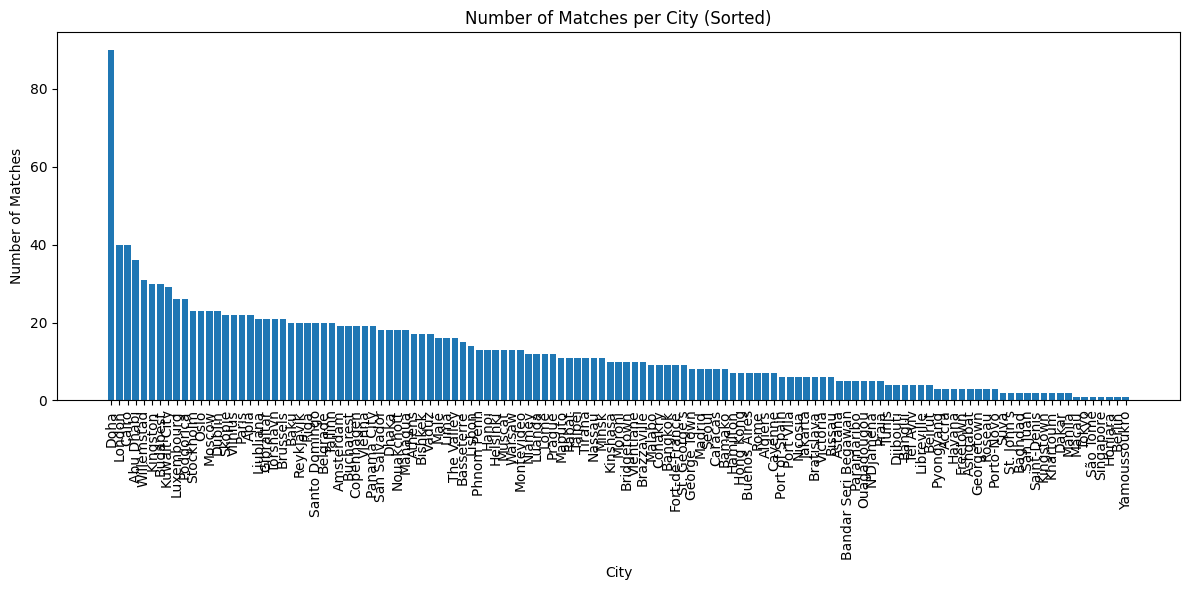

In [ ]:
# prompt: Visualize the count for each  city as stored in city_counts ordered in descending order

city_counts_sorted = city_counts.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(city_counts_sorted.index, city_counts_sorted.values)
plt.xlabel('City')
plt.ylabel('Number of Matches')
plt.title('Number of Matches per City (Sorted)')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


Overall, we have only 1571 matches for which we have weather data. While this covers capitals of 125 countries, the amount of data is quite small. Moreover, the histogram shows that for most cities, there are less than 30 readings, so the data available for each climate region is small.

**Quality considerations**



*   Completeness of this dataset is not adequate for our task at hand. While there are some missing weather readings on some dates across locations, the dataset lacks precipitation data and its scope limiting to approx. 5 years and capitals only is too small.
*   The documentation of the content of the data set is commendable, all units of measure and the meaning of colums are documented and the description clearly states the scope of the dataset.



**Conclusion for Historical Weather Data for Capitals**

We disregard the dataset DS3 from further consideration after careful exploration because it is incomplete in several regards, resulting in too small an amount of data to be appropriate for the task at hand.

### DS4: The Weather Dataset

**Description.** Upon loading the data with the standard reader, an error message occured (footer missing), so an alternative engine is used. This allows to read in data, however, the sample data printed shows NaN readings for quite a few weather statistics. These are for quite dated readings, so it is possible that the measurements are not available there. Further exploration is needed to study the completeness of the data with respect to our task. Besides that, we note that information about city, measurement data, temperature, precipitation, snow, and wind are modeled, covering a good range of climate variables to consider in our analysis.

In [ ]:
# prompt: Load dataframe from a parquet file that is missing footer


# Attempt to load the Parquet file, ignoring the footer issue
df_weather = pd.read_parquet('sample_data/daily_weather.parquet', engine='pyarrow')

# Print the DataFrame to verify it loaded correctly
print(df_weather.head())


  station_id city_name       date  season  avg_temp_c  min_temp_c  max_temp_c  \
0      41515  Asadabad 1957-07-01  Summer        27.0        21.1        35.6   
1      41515  Asadabad 1957-07-02  Summer        22.8        18.9        32.2   
2      41515  Asadabad 1957-07-03  Summer        24.3        16.7        35.6   
3      41515  Asadabad 1957-07-04  Summer        26.6        16.1        37.8   
4      41515  Asadabad 1957-07-05  Summer        30.8        20.0        41.7   

   precipitation_mm  snow_depth_mm  avg_wind_dir_deg  avg_wind_speed_kmh  \
0               0.0            NaN               NaN                 NaN   
1               0.0            NaN               NaN                 NaN   
2               1.0            NaN               NaN                 NaN   
3               4.1            NaN               NaN                 NaN   
4               0.0            NaN               NaN                 NaN   

   peak_wind_gust_kmh  avg_sea_level_pres_hpa  sunshine_

In [ ]:
#  Print column names of df and df_weather

print(df.columns)
print(df_weather.columns)


Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')
Index(['station_id', 'city_name', 'date', 'season', 'avg_temp_c', 'min_temp_c',
       'max_temp_c', 'precipitation_mm', 'snow_depth_mm', 'avg_wind_dir_deg',
       'avg_wind_speed_kmh', 'peak_wind_gust_kmh', 'avg_sea_level_pres_hpa',
       'sunshine_total_min'],
      dtype='object')


**Exploratory steps**

With the comprehensive football match data we have, we need complete weather data with respect to weather conditions at matches. We therefore join the two data frames on city and date and analyze the resulting data.

In [ ]:
# Python for SQL query SELECT * FROM df, df_weather WHERE df.city = df_weather.city_name AND df.date = df_weather.date

# Convert 'date' columns to datetime objects
if not pd.api.types.is_datetime64_any_dtype(df['date']):
  df['date'] = pd.to_datetime(df['date'])
if not pd.api.types.is_datetime64_any_dtype(df_weather['date']):
  df_weather['date'] = pd.to_datetime(df_weather['date'])

# Rename the city column in df_weather to match the column name in df
df_weather = df_weather.rename(columns={'city_name': 'city'})

# Perform the inner join on 'city' and 'date' columns
merged_df_2 = pd.merge(df, df_weather, on=['city', 'date'], how='inner')

# Print the merged DataFrame
print(merged_df_2)


            date         home_team    away_team  home_score  away_score  \
0     1900-03-17  Northern Ireland      England           0           2   
1     1902-10-12           Austria      Hungary           5           0   
2     1903-10-11           Austria      Hungary           4           2   
3     1904-03-26  Northern Ireland     Scotland           1           1   
4     1904-05-01           Belgium       France           3           3   
...          ...               ...          ...         ...         ...   
20294 2023-08-27           Bolivia       Panama           1           2   
20295 2023-08-28           Comoros      Réunion           1           1   
20296 2023-08-28         Mauritius   Seychelles           1           0   
20297 2023-09-03        Bangladesh  Afghanistan           0           0   
20298 2023-09-04        Mozambique        Benin           3           2   

                                 tournament          city     country  \
0                 British 

There are 20299 rows joining matches with weather. This is a significant number of rows on which to base our analysis. Before deciding on using the dataset, we however need to check that the weather data is not too sparse, as the excerpt again exibits NaN values. We also need to check that different geographies are sufficiently covered in this combined dataset

We start our exploration with the geographical coverage with available weather data. For this, we explore the cities and countries covered.

In [ ]:
# prompt: SELECT city, country, COUNT(*) FROM merged_df_2 GROUP BY city, country

city_country_counts = merged_df_2.groupby(['city', 'country'])['city'].count()
print(city_country_counts)


city            country             
Aalborg         Denmark                   6
Abha            Saudi Arabia              3
Abidjan         Ivory Coast             170
Abu Dhabi       United Arab Emirates    228
Accra           Ghana                    68
                                       ... 
Zürich          Switzerland              84
Ústí nad Labem  Czech Republic            1
İzmir           Turkey                    2
Ōita            Japan                    10
Šibenik         Croatia                   1
Name: city, Length: 562, dtype: int64


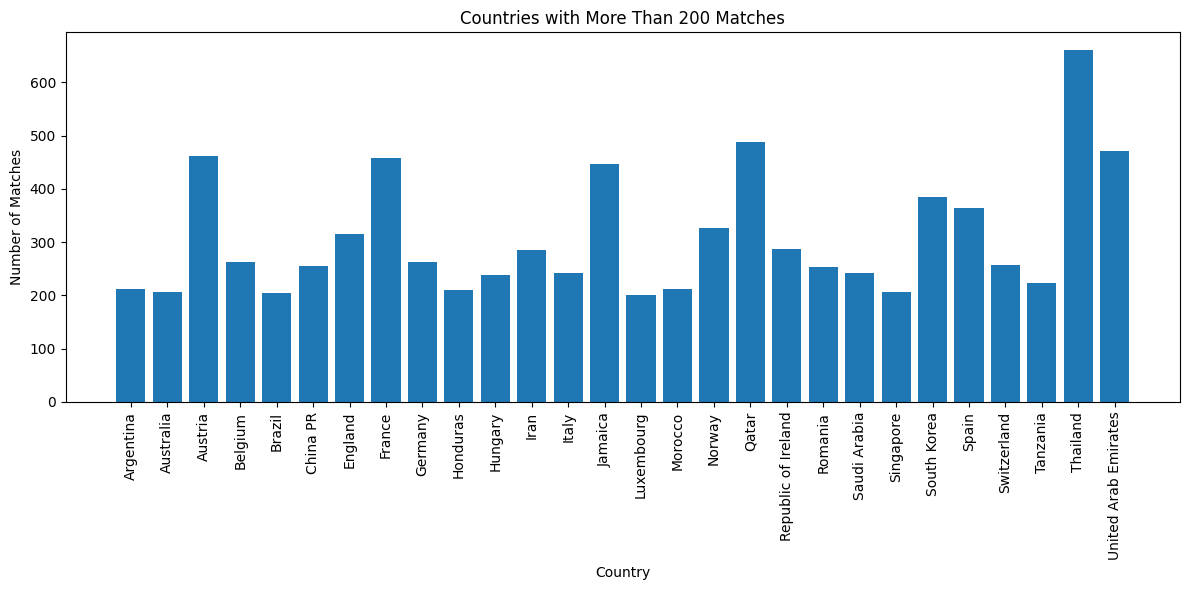

In [ ]:
# prompt: Visualize for each country the result of SELECT country, SUM(count) FROM city_country_counts GROUP BY country HAVING SUM(count) > 200

# Assuming city_country_counts is a pandas Series as described in the preceding code
country_counts = city_country_counts.groupby('country').sum()

# Filter countries with a sum of counts greater than 200
filtered_country_counts = country_counts[country_counts > 200]

# Create a bar plot to visualize the results
plt.figure(figsize=(12, 6))
plt.bar(filtered_country_counts.index, filtered_country_counts.values)
plt.xlabel('Country')
plt.ylabel('Number of Matches')
plt.title('Countries with More Than 200 Matches')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


From the above analysis, we see that the number of cities and contries as well as their worldwide coverage is still large, and additionally taking into account the number of matches within each country (see plot), the countries with more than 200 tuples are still varied enough in terms of climate. We therefore conclude this weather data rich enough in its records in terms of geographical coverage for the purpose of our analysis.

We now move on to the adequacy of the data in individual attribute values. This exploration is triggered by the previoulsy observed NaN values, where we need to find out if the weather data is dense enough for our application. In addition, the weather data not having a country attribute, our join over city and data may be ambiguous (same city names in different countries are possible). We therefore also include data profiling to investigate the correctness of the city-to-country mapping.

In [ ]:
# prompt: Create a table that lists, for each attribute of merged_df_2, the number of NaN values of that column and the percentage this number represents compared to the total number of values in a column.

# Calculate the number of NaN values for each column
nan_counts = merged_df_2.isnull().sum()

# Calculate the total number of values for each column
total_counts = merged_df_2.shape[0]

# Calculate the percentage of NaN values for each column
nan_percentages = (nan_counts / total_counts) * 100

# Create a DataFrame to store the results
nan_table = pd.DataFrame({'NaN Count': nan_counts, 'NaN Percentage (%)': nan_percentages})

# Print the table
print(nan_table)


                        NaN Count  NaN Percentage (%)
date                            0            0.000000
home_team                       0            0.000000
away_team                       0            0.000000
home_score                      0            0.000000
away_score                      0            0.000000
tournament                      0            0.000000
city                            0            0.000000
country                         0            0.000000
neutral                         0            0.000000
station_id                      0            0.000000
season                          0            0.000000
avg_temp_c                   2106           10.374895
min_temp_c                   3715           18.301394
max_temp_c                   3102           15.281541
precipitation_mm             7200           35.469728
snow_depth_mm               18568           91.472486
avg_wind_dir_deg            15692           77.304301
avg_wind_speed_kmh          

We see that most weather attributes are quite sparse, featuring a majority of NULL values. Therefore, we shall only rely on the more dense weather attributes of temperature and precipitation for our analysis.

The next code considers the possible inaccuracies the join may have introduced. To this end, we explore the number of countries associated to each city in DS1. a same city label in the original DS1.

In [ ]:
# prompt: SELECT  city, COUNT(DISTINCT Country) FROM df GROUP BY city HAVING COUNT(DISTINCT Country) > 1 ORDER BY COUNT(DISTINCT COUNTRY)

# Assuming 'df' is your DataFrame with match data
non_unique_cities = df.groupby('city')['country'].nunique()
non_unique_cities = non_unique_cities[non_unique_cities > 1]
#print(non_unique_cities.sort_values(ascending=False))
print(non_unique_cities)


city
Accra         2
Aden          2
Alderney      2
Alexandria    2
Apia          2
             ..
Yerevan       2
Zagreb        2
Zenica        2
Zhuhai        2
Zomba         2
Name: country, Length: 115, dtype: int64


We observe that 115 cities appear in more than one country. This may cause wrong associations to weather data. We further investigate these cases by showing the countries associated to these cities.

In [ ]:
# prompt: SELECT distinct city, country FROM df WHERE city IN  (SELECT city FROM (SELECT  city, COUNT(DISTINCT Country) FROM df GROUP BY city HAVING COUNT(DISTINCT Country) > 1) )ORDER BY city

# Assuming 'merged_df_2' and 'df' are your DataFrames
# We want to select distinct city and country from merged_df_2
# where the city is in the list of cities that appear in more than one country in df.

#cities_in_multiple_countries = df.groupby('city')['country'].nunique()
non_unique_cities_list = non_unique_cities.index.tolist()

result_df = df[df['city'].isin(non_unique_cities_list)][['city', 'country']].drop_duplicates().sort_values('city')

print(result_df)


           city                 country
4545      Accra                   Ghana
3335      Accra              Gold Coast
34326      Aden                   Yemen
9686       Aden               Yemen DPR
27332  Alderney                Guernsey
...         ...                     ...
20921    Zenica  Bosnia and Herzegovina
42430    Zhuhai                   Macau
34394    Zhuhai                China PR
6049      Zomba               Nyasaland
7566      Zomba                  Malawi

[245 rows x 2 columns]


In [ ]:
# prompt: for each row in result_df, print its values

for index, row in result_df.iterrows():
  print(row.values)


['Accra' 'Ghana']
['Accra' 'Gold Coast']
['Aden' 'Yemen']
['Aden' 'Yemen DPR']
['Alderney' 'Guernsey']
['Alderney' 'Alderney']
['Alexandria' 'Egypt']
['Alexandria' 'United Arab Republic']
['Apia' 'Western Samoa']
['Apia' 'Samoa']
['Arad' 'Iran']
['Arad' 'Bahrain']
['Arad' 'Romania']
['Asmara' 'Eritrea']
['Asmara' 'Ethiopia']
['Bamako' 'Mali']
['Bamako' 'Malawi']
['Bamako' 'Mali Federation']
['Belfast' 'Northern Ireland']
['Belfast' 'Ireland']
['Belgrade' 'Yugoslavia']
['Belgrade' 'Serbia and Montenegro']
['Belgrade' 'Serbia']
['Berlin' 'German DR']
['Berlin' 'Germany']
['Birmingham' 'England']
['Birmingham' 'United States']
['Bissau' 'Portuguese Guinea']
['Bissau' 'Guinea-Bissau']
['Blantyre' 'Malawi']
['Blantyre' 'Nyasaland']
['Bobo Dioulasso' 'Burkina Faso']
['Bobo Dioulasso' 'Upper Volta']
['Bondoufle' 'Kenya']
['Bondoufle' 'France']
['Bratislava' 'Czechoslovakia']
['Bratislava' 'Slovakia']
['Brazzaville' 'Belgian Congo']
['Brazzaville' 'Congo']
['Brest' 'Belarus']
['Brest' 'France'

We see that during data preparation, the integration of the datasets will require advanced data cleaning techniques due to the ambiguity of city and country names in the data set. In the above result, we observe the following problems:

*   Incomplete names, e.g., Vietnam vs. Vietnam Republic
*   Different granularity, e.g., Reunion vs France (Reunion is a region of France)
* Evolving / outdated countries, e.g., Myanmar vs Burma, Odessa in the Soviet Union vs Ukraine or Magdeburg Germany vs Germany DR
* Varying language, e.g., Eire vs Ireland or Czechoslovakia vs Czech Republic.
* Same name in different countries, e.g., Cordoba in Spain and Argentina.

While The first four issues do not pose a problem to our analysis (the cities are correctly associated to their weather or filtered out because the other source does not include these cities), the last issue may associate a city to wrong data. During data preparation, we can resolve this by properly joining via the additional table provided by the same data source that associates sensor_ID with city, country, and GPS coordinates - we may need to deal with the synonymous representations of countries then to maximize number of joined rows that form the basis for our analysis.



**Quality considerations**

Two examples of quality criteria our exploration helps asses.

*   The relevancy of the dataset is good, as its weather data is applicable and helpful for the task at hand.
*   The completeness is sufficient with respect to geographies covered but it could be better in terms of weather data, as most weather statistics are NULL.



**Conclusion for the Weather Data (DSA)**

Overall, we consider this dataset adequate for our analytical task: it matches the requirements and sufficiently combines with the match data to provide a large enough and diverse data basis for our analysis. While we observed a few data quality issues that may hamper analysis, we described how these can be addressed during data preparation. These relate to the disambiguation and standardization of country names and correct integration of the datasets. We note that there are quite a few NULL values in the weather statistics we plan to further consider (temperature and precipitation). If the remaining data are too small to create an accurate model, we may explore ways to accurately impute the data to reduce sparsity.

### DS5: The Weather API

**Description**. The Weather API (free version) allows to retrieve data about precipitation, temperatures, etc. via date, latitude, and longitude. It stores records from 1979 onwards, which covers a substantial date range. Given the sensor locations in S4, we can link latitude and longitude to cites where matches took place. The API allows to retrieve weather data at different granularities, including daily summaries, which is compatible with our requirements. We may use this source, denoted as DS5, to compensate for missing data from the previous dataset, assuming the underlying data is more complete than DS4.

**Exploratory steps**

The API allows 1000 free calls a day. We wrap a call in the function get_historical_weather.

In [ ]:
#This function calls the API and takes as parameters the date as a string, latitude, and longitude.

def get_historical_weather(dateString, latitude, longitude):

  date = datetime.strptime(dateString, '%Y-%m-%d').date()


  base_url = "https://api.openweathermap.org/data/3.0/onecall/day_summary"
  params = {
      "lat": latitude,
      "lon": longitude,
      "date" : date,
      "appid": "be27001acbd0c643f7e4db41da07cd34",
      "units": "metric"
  }

  try:
    response = requests.get(base_url, params=params)
    response.raise_for_status()  # Raise an exception for bad status codes
    data = response.json()
    return data
  except requests.exceptions.RequestException as e:
    print(f"Error retrieving weather data: {e}")
    return None


Given the limitation to 1000 calls per day, we continue to limit to the features with a small amount of missing values to be able to retrieve the missing data in reasonable amount of time for the Prepare stage of our project. In addition, we can only consider those features for which the API also returns values. That is, we only further consider min_temp_c, max_temp_c, precipitation_mm (the average temperature being present and mostly populated in DS4, but not present in DS5).

Over time, we obtained additional weather data for specific dates and locations, where one of the three considered readings was previously missing. Upon exploring this data, we note that while temperature readings are comparable and compatible among the two sources, precipitation values do not agree / it is unclear how the relate to one another. This means that the collected data is only useful to complete missing temperature values (for min and max temperature).

**Quality consideration**

From the above exploration of the dataset, we make the following observations in terms of data quality:


*   Completeness: for dates > 1979, DS5 offers a quite complete range of readings that is useful to completent more spare data obtained from other datasets.
*   Accuracy: While the temperature readings are consistent with existing readings from other sources, precipitation as reported in DS5 significantly differs without a clear pattern or relationship from weather data from DS4. Hence, the accuracy of precipitation readings seems to be low (in either of the sources).



**Concluding discussion**

Overall, the data of DS5 is useful for our application, but with a narrower scope than initially expected. First, due to technical limitations (number of API calls), we limit obtaining data missing from DS4 only for the features with a low number of null values. Among these features, it turned out that only 3 are available in DS5 and after profiling data of these features, one needs to be discarded due to poor quality (i.e., precipitation). This means that this data source will only offer additional value for analysis tasks relating to temperature. These, however, certainly benefit from less missing values, so we retain DS5 for further consideration.

## Data Preparation (Process)



> *In this section, describe, justify, and implement transoformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:
*   Overview: provides a summary of the transformations performed, reffering to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.
*   For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.





### Overview

As part of data preparation, we implement the transformation and profiling tasks summarized in the diagram below. Relying on the data obtained from CSV files in DS1 and DS4, we retain only their necessary attributes and build an integrated dataset. Upon profiling missing values, we opt to leverage data that was incrementally obtained from DS5 (due to daily access quotas) to impute missing values in the weather data. Next, we enrich the data with two additional attributes: one binary attribute distinguishing friendly matches from competitive matches and one categorical attribute defining the climate zone of a match location. Profiling the value distribution of these new attributes yields satisfactory results and we persistently store the prepared dataset before further processing.

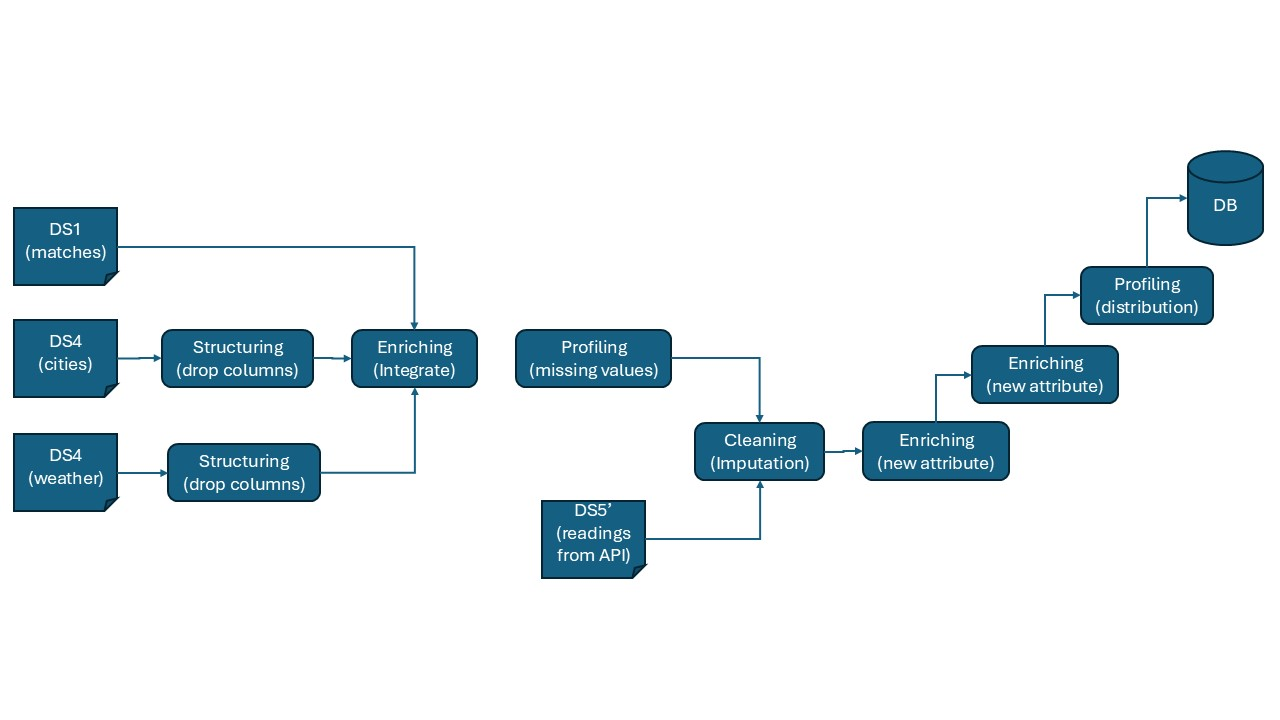

In [ ]:
#Open connection for this stage of processing
conn = sqlite3.connect('projectDB.sqlite')

### Structuring data from DS4

**Dropping irrelevant columns from cities.csv**

Some of the columns provided in the original file are irrelevant for our application. We remove these colums as part of a structuring operation.

In [ ]:
#Get data about station locations (data from DS4) with schema
#(station_id, city_name, country, latitude, longitude)
#This implements a first transformation where irrelevant columns from the source are removed (i.e., state, iso2, iso3)
sensor_loc_df = pd.read_csv('sample_data/cities.csv')
station_locations = sensor_loc_df.drop(columns=['state', 'iso2', 'iso3']).to_sql(name="station_locations", con=conn, if_exists='replace', index=False)


**Dropping irrelevant columns from the weather parquet file**

Similarly, we remove all attributes from the weather dataset that we recognized as being too sparse and too costly to fix through data imputation during our initial exploratory analysis of the datasets.

In [ ]:
#From the weather data, we only keep the usable attributes as determined by our
#exploratory analysis.
weather_data = df_weather.drop(columns=['city', 'avg_temp_c', 'snow_depth_mm',
                                        'avg_wind_dir_deg', 'avg_wind_speed_kmh',
                                        'peak_wind_gust_kmh', 'avg_sea_level_pres_hpa',
                               'sunshine_total_min'])

print(weather_data)

      station_id       date  season  min_temp_c  max_temp_c  precipitation_mm
0          41515 1957-07-01  Summer        21.1        35.6               0.0
1          41515 1957-07-02  Summer        18.9        32.2               0.0
2          41515 1957-07-03  Summer        16.7        35.6               1.0
3          41515 1957-07-04  Summer        16.1        37.8               4.1
4          41515 1957-07-05  Summer        20.0        41.7               0.0
...          ...        ...     ...         ...         ...               ...
24216      67975 2023-09-01  Spring         9.6        28.4               NaN
24217      67975 2023-09-02  Spring        10.5        31.4               NaN
24218      67975 2023-09-03  Spring        13.0        31.5               NaN
24219      67975 2023-09-04  Spring        13.1        29.7               NaN
24220      67975 2023-09-05  Spring        14.0        27.3               NaN

[27635763 rows x 6 columns]


### Enriching match data from DS1 through integration

Due to limited memory, we cannot directly load the weather data into a SQLite table. Therefore, we first filter the weather dataset to only include tuples with station_ids of match locations and weather readings on match dates. The result is then written to a database table such that we can perform the integration of the datasets via join operations.

In [ ]:
#Get data about match results (data from DS1) with schema
#(date,home_team, away_team,  home_score,  away_score, tournament, city, country, neutral)
match_results = df.to_sql(name="match_results", con=conn, if_exists='replace', index=False)


In [ ]:
#From weather_data, we are only interested in data matching a station_id at
#a match location, so we retrieve these stations and filter weather_data based
#on retrieved station_ids

sql_relevant_station_ids = "SELECT DISTINCT station_ID FROM match_results MR, station_locations SL \
  WHERE MR.city = SL.city_name AND MR.country = SL.country"
stations_with_matches = pd.read_sql(sql_relevant_station_ids, conn)

weather_data_filtered = weather_data[weather_data['station_id'].isin(stations_with_matches['station_id'])]

#we further prune the weather data based on match dates
sql_distinct_match_dates_with_stations = "SELECT DISTINCT date \
     FROM match_results MR, station_locations SL \
    WHERE MR.city = SL.city_name AND MR.country = SL.country"

distinct_match_dates = pd.read_sql(sql_distinct_match_dates_with_stations, conn)
#print(distinct_match_dates)

#we apply the match date filter and store the result in the DB
weather_data_filtered_2 = weather_data_filtered[weather_data_filtered['date'].isin(distinct_match_dates['date'])].to_sql(name="weather_data", con=conn, if_exists='replace', index=True)


<ipython-input-35-0e783a7cbb06>:20: FutureWarning: The behavior of 'isin' with dtype=datetime64[us] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  weather_data_filtered_2 = weather_data_filtered[weather_data_filtered['date'].isin(distinct_match_dates['date'])].to_sql(name="weather_data", con=conn, if_exists='replace', index=True)


In [ ]:
#We can now execute the following query to integrate the data
# to obtain matches with weather data and remove redundant or irrelevant columns

query1 = "SELECT MR.*, SL.station_id, SL.latitude, SL.longitude, WD.season, WD.min_temp_c, WD.max_temp_c, WD.precipitation_mm  \
  FROM match_results MR, station_locations SL, weather_data WD \
  WHERE MR.city = SL.city_name AND MR.country = SL.country \
  AND WD.station_id = SL.station_id AND WD.date = MR.date"
r1 = pd.read_sql(query1, conn)
print(r1)

                      date         home_team    away_team  home_score  \
0      1900-03-17 00:00:00  Northern Ireland      England           0   
1      1902-10-12 00:00:00           Austria      Hungary           5   
2      1903-10-11 00:00:00           Austria      Hungary           4   
3      1904-03-26 00:00:00  Northern Ireland     Scotland           1   
4      1904-05-01 00:00:00           Belgium       France           3   
...                    ...               ...          ...         ...   
18685  2023-08-27 00:00:00           Bolivia       Panama           1   
18686  2023-08-28 00:00:00           Comoros      Réunion           1   
18687  2023-08-28 00:00:00         Mauritius   Seychelles           1   
18688  2023-09-03 00:00:00        Bangladesh  Afghanistan           0   
18689  2023-09-04 00:00:00        Mozambique        Benin           3   

       away_score                            tournament          city  \
0               2             British Home Champio

### Profiling missing values

We verify the density of the data by counting the number of nulls per attribute. This corresponds to another round of profiling to reveal data quality issues that may need fixing prior to analysis.

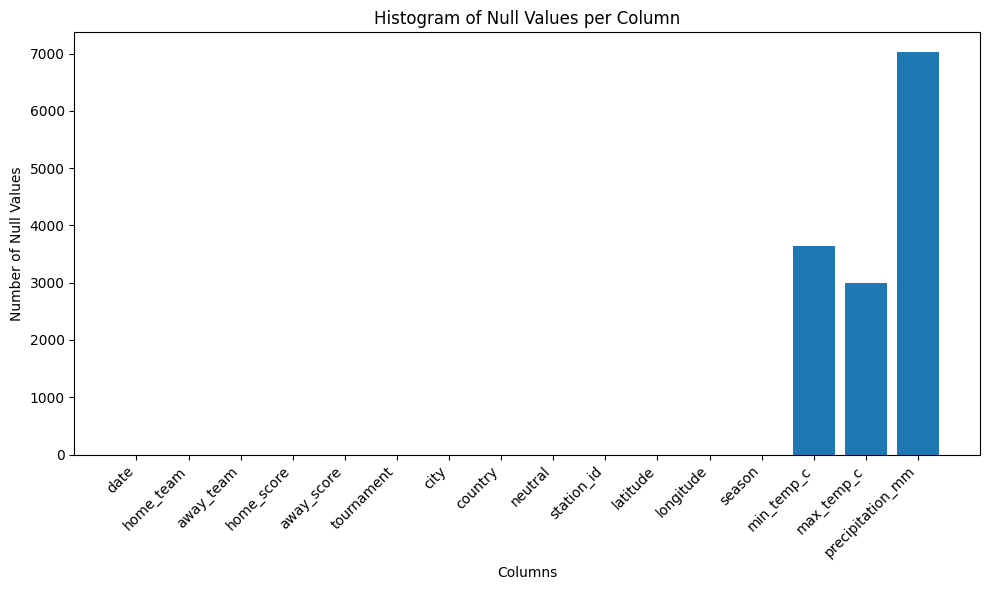

In [ ]:
null_counts = r1.isnull().sum()

plt.figure(figsize=(10, 6))
plt.bar(null_counts.index, null_counts.values)
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.title("Histogram of Null Values per Column")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


### Data cleaning through data imputation

 As detected during our initial profiling, the weather data is sparse, and we use data from DS5 to perform data imputation for missing values (to be done once the required data is fully harvested.)

### Enriching by new attribute match_type

Our analysis does not require the distinction of different tournaments. However, we would like to keep the information of whether a match was a friendly match or a competitive match, as this may influence the quality of the selection playing or the motivation of players. This extends the table by an additional binary attribute.

In [ ]:

# Create the new column 'match_type'
r1['match_type'] = r1['tournament'].apply(lambda x: 0 if x == 'Friendly' else 1)

### Structuring by dropping tournament column

In [ ]:
r1.drop(columns=['tournament'], inplace=True)

print(r1)

                      date         home_team    away_team  home_score  \
0      1900-03-17 00:00:00  Northern Ireland      England           0   
1      1902-10-12 00:00:00           Austria      Hungary           5   
2      1903-10-11 00:00:00           Austria      Hungary           4   
3      1904-03-26 00:00:00  Northern Ireland     Scotland           1   
4      1904-05-01 00:00:00           Belgium       France           3   
...                    ...               ...          ...         ...   
18685  2023-08-27 00:00:00           Bolivia       Panama           1   
18686  2023-08-28 00:00:00           Comoros      Réunion           1   
18687  2023-08-28 00:00:00         Mauritius   Seychelles           1   
18688  2023-09-03 00:00:00        Bangladesh  Afghanistan           0   
18689  2023-09-04 00:00:00        Mozambique        Benin           3   

       away_score          city     country  neutral station_id   latitude  \
0               2        Dublin     Ireland  

### Enriching by new attribute climate_zone

To associate match locations with climate zones, we resort to a simple classification (as we could not find any secondary source for a more fine-grained enrichment). We follow the following definition:
*   Tropical: absolute latitude in [0, 23.5[
*   Subtropical: " [23.5, 40[
*   Temperate: " [40 - 60[
*   Cold:  " [60 - 90]





In [ ]:
def assign_climate_zone(latitude):
    latitude = abs(latitude)
    if 0 <= latitude < 23.5:
        return 'Tropical'
    elif 23.5 <= latitude < 40:
        return 'Subtropical'
    elif 40 <= latitude < 60:
        return 'Temperate'
    elif 60 <= latitude <= 90:
        return 'Cold'
    else:
        return 'Unknown'  # Handle cases outside the defined ranges

r1['climate_zone'] = r1['latitude'].apply(assign_climate_zone)

print(r1)


                      date         home_team    away_team  home_score  \
0      1900-03-17 00:00:00  Northern Ireland      England           0   
1      1902-10-12 00:00:00           Austria      Hungary           5   
2      1903-10-11 00:00:00           Austria      Hungary           4   
3      1904-03-26 00:00:00  Northern Ireland     Scotland           1   
4      1904-05-01 00:00:00           Belgium       France           3   
...                    ...               ...          ...         ...   
18685  2023-08-27 00:00:00           Bolivia       Panama           1   
18686  2023-08-28 00:00:00           Comoros      Réunion           1   
18687  2023-08-28 00:00:00         Mauritius   Seychelles           1   
18688  2023-09-03 00:00:00        Bangladesh  Afghanistan           0   
18689  2023-09-04 00:00:00        Mozambique        Benin           3   

       away_score          city     country  neutral station_id   latitude  \
0               2        Dublin     Ireland  


### Profiling value distribution of new attributes

We profile the new columns, looking at their value distributions. This helps us assess characteristics of the data that could impact the analyis.

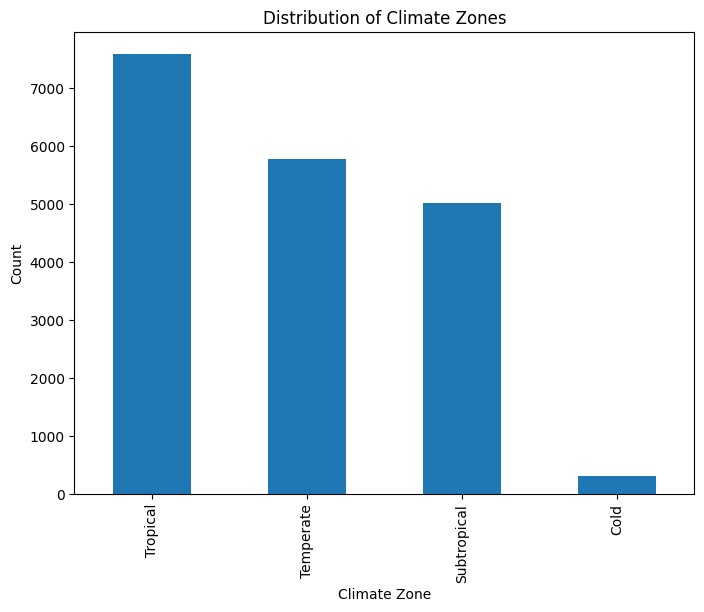

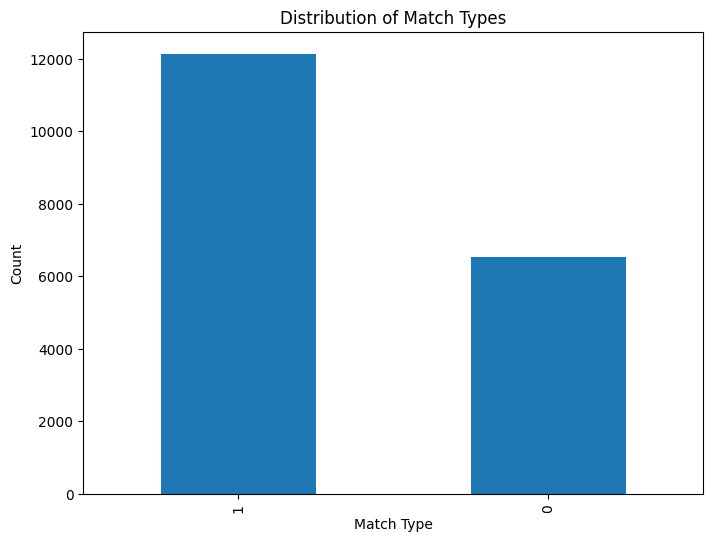

In [ ]:
# prompt: generate histogram for value distribution of climate_zone and match_type in r1


# Histogram for 'climate_zone'
plt.figure(figsize=(8, 6))
r1['climate_zone'].value_counts().plot(kind='bar')
plt.title('Distribution of Climate Zones')
plt.xlabel('Climate Zone')
plt.ylabel('Count')
plt.show()

# Histogram for 'match_type'
plt.figure(figsize=(8, 6))
r1['match_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Match Types')
plt.xlabel('Match Type')  # 0 for Friendly, 1 for others
plt.ylabel('Count')
plt.show()


We note that matches in the cold climate zone are underrepresented, which is not surprising but may cause some bias during analysis if not dealt with properly. Match types are also unbalanced (in favor of competitive matches) and we will make dedicated analysis for each class.

In [ ]:
r1.to_csv('r1.csv')
conn.close()

## Data Analysis (Analyze)


> *Clearly state which type of analysis you conduct (descriptive, diagnostic, predictive, prescriptive) and the methods you use (e.g., time series decomposition, root cause analysis, etc.). Your project should include at least one analysis. When conducting several analysis techniques / methods, specify each of them.*





Given that our ovarching goal is to determine if there is a relationship between match results and climate conditions, we apply the following methods from descriptive / diagnostic analytics:

*   Visualization (Descriptive analysis)
*   Relationship and dependency analysis (Diagnostic analysis)
*   Hypothesis testing and validation (Diagnostic analysis)
*  ...


In [ ]:
#read input file for analysis
df = pd.read_csv('sample_data/r1.csv')



> *For each analysis, briefly describe its goal, justify the methods / measures used, show the code performing the analysis, interpret the result, and discuss possible limitations of your approach. Follow the structure as illustrated below.*


### Visualization

**Goal:** The goal is to visually describe the distribution of scores for the different climate zones.

**Methods / measures:** We use box plots as compact visualization of each distribution.

**Code:** For each climate zone, we generate a box plot.

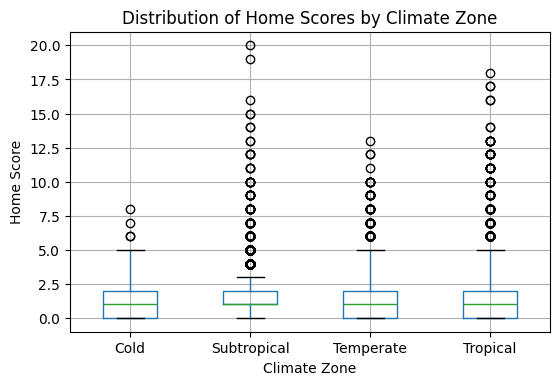

In [ ]:
# Create the box plot
df.boxplot(column='home_score', by='climate_zone', figsize=(6, 4))
plt.title('Distribution of Home Scores by Climate Zone')
plt.suptitle('')  # Remove the default suptitle
plt.ylabel('Home Score')
plt.xlabel('Climate Zone')
plt.show()


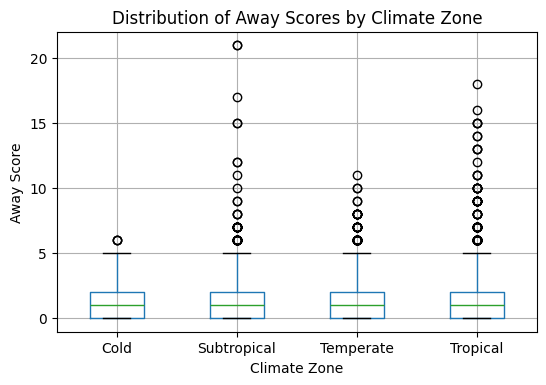

In [ ]:
# Create the box plot
df.boxplot(column='away_score', by='climate_zone', figsize=(6, 4))
plt.title('Distribution of Away Scores by Climate Zone')
plt.suptitle('')  # Remove the default suptitle
plt.ylabel('Away Score')
plt.xlabel('Climate Zone')
plt.show()


**Interpretation.** The mean and measures of dispersion visualized by the boxplot indicate a comparable distribution for both home and away scores in different climate zones. We observe a high range of values in subtropical and tropica regions, while it is smaller in the cold region. However, as we have noticed while profiling our data, the cold region is underrepresented in the dataset so we must be cautious in drawing any conclusion here.

**Limitations.** We are aware that our division into climate zones is very coarse grained and generic, which may cause hidden relationships not to be discovered. Using the above visual analysis gives an indication that there is no significant difference in score distribution within the selected climate zones, but drawing a general conclusion based on our data sample would require some follow-up statistical analysis (see hypothesis testing below).

### Relationship and dependency analysis

**Goal.**
The goal is to identify if there is a relationship between match results and weather during matches / climate at match location.

**Methods / measures.**
We apply a correlation analysis. Given that we are not dealing with continuous data only and the type of data and distribution of, the Spearman correlation is the more appropriate choice.

**Code.** The following code computes the Spearman correlation between match score summaries (i.e., sum of goals, goal difference, max goals, min goals) and climate factors(i.e., precipitation, maximum temperature, combination of season and climate zone).

In [ ]:
#add columns for score summaries

df['sum_goals'] = df['home_score'] + df['away_score']
df['goals_diff'] = abs(df['home_score'] - df['away_score'])
df['max_goals'] = df[['home_score', 'away_score']].max(axis=1)
df['min_goals'] = df[['home_score', 'away_score']].min(axis=1)

#add additional column combining season and climate_zone
df['season_climate_zone'] = df['season'] + '_' + df['climate_zone']


In [ ]:
# Remove rows where 'precipitation_mm' is NaN
#df_cleaned_for_corr = df.dropna(subset=['precipitation_mm'])


score_summary_columns = ['sum_goals', 'goals_diff', 'max_goals', 'min_goals']

#Spearman correlation wrt season_climnate_zone
for score_col in score_summary_columns:
  correlation, p_value = stats.spearmanr(df[score_col], df['season_climate_zone'])
  print(f"Spearman correlation between {score_col} and {'season_climante_zone'}: {correlation}, p-value: {p_value}")

#Spearman correlation wrt precipitation_mm where we need to remove NaN values
df_cleaned_for_corr = df.dropna(subset=['precipitation_mm'])
for score_col in score_summary_columns:
  correlation, p_value = stats.spearmanr(df_cleaned_for_corr[score_col], df_cleaned_for_corr['precipitation_mm'])
  print(f"Spearman correlation between {score_col} and {'precipitation_mm'}: {correlation}, p-value: {p_value}")

#Spearman correlation wrt max_temp_c where we need to remove NaN values
df_cleaned_for_corr_maxT = df.dropna(subset=['max_temp_c'])
for score_col in score_summary_columns:
  correlation, p_value = stats.spearmanr(df_cleaned_for_corr_maxT[score_col], df_cleaned_for_corr_maxT['max_temp_c'])
  print(f"Spearman correlation between {score_col} and {'max_temp_c'}: {correlation}, p-value: {p_value}")



Spearman correlation between sum_goals and season_climante_zone: -0.01244991052362495, p-value: 0.0887560239654214
Spearman correlation between goals_diff and season_climante_zone: -0.03302790325944699, p-value: 6.295323682556515e-06
Spearman correlation between max_goals and season_climante_zone: -0.023715552280550688, p-value: 0.0011851718190513435
Spearman correlation between min_goals and season_climante_zone: 0.015500762829373278, p-value: 0.03408065091844771
Spearman correlation between sum_goals and precipitation_mm: 0.03159636237696675, p-value: 0.0006403592999509602
Spearman correlation between goals_diff and precipitation_mm: 0.03197081846449606, p-value: 0.0005515240787141272
Spearman correlation between max_goals and precipitation_mm: 0.03585268125381395, p-value: 0.00010702743414413086
Spearman correlation between min_goals and precipitation_mm: 0.010657736132196205, p-value: 0.24961286261927504
Spearman correlation between sum_goals and max_temp_c: -0.0015862704487504395,

**Interpretation.**
All correlation scores are close to 0, meaning that no relationship between the studied combinations of score-climate-factores can be detected.

**Limitations**. The above analysis does not take into account the region teams come from. This may be an additional factor to consider. Goal-related statistics may not be the only relevant statistics to assess game play, but it is what we obtained from the data sources we found and could use.

### Hypothesis testing

**Goal.** Given the results of our visual analysis, we want to determine if cold climate / cold game conditions significantly affect match results, as we have observed that these are lower for the Cold climate zone than for the others.

**Methods / Measures.** We use hypothesis testing. Our Null-hypothesis is that there is no difference between match results (we will focus home_score and away_score) in Cold climate / weather (below 10 degrees) and warmer weather. The alternative hypothesis is that there is a significant difference. As test statistics, we choose the Mann-Whitney U test given that we compare two non-normal distributions of same shape (see first visualization of the code section) with a continuous dependent variable (score) and an independent variable "climate" with two groups (COLD/WARM).

**Code.** The first part of our code is used to determine which statistical test to use. The second part performs the test based on the climate zone and the temperature, respectively.

In [ ]:
# Create TEMP_CLASS column based on max_temp_c
df['TEMP_CLASS'] = np.where(df['max_temp_c'] < 10, 'COLD', 'WARM')

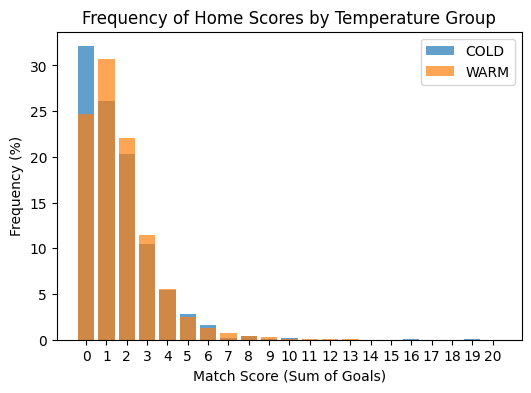

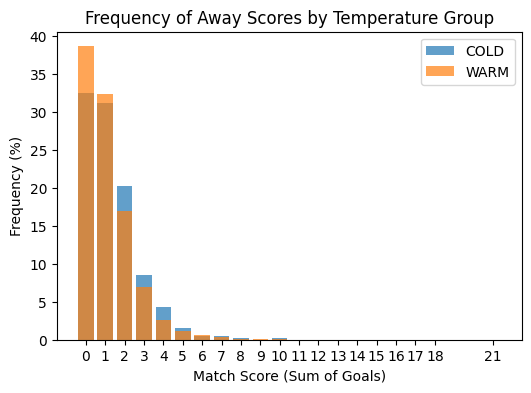

In [ ]:
#We compare the distribution of scores among the different groups to see if it follows a normal distribution or has similar shape across groups.
#Given the high difference in number of samples in both classes profiled before, we make a %-wise comparison
# Group data based on max_temp_c
cold_group = df[df['TEMP_CLASS'] == 'COLD']
warm_group = df[df['TEMP_CLASS'] == 'WARM']

# Calculate total matches for each group
total_cold_matches = len(cold_group)
total_warm_matches = len(warm_group)

# Function to calculate score frequencies for home_score
def calculate_score_frequencies(group, total_matches, att):
    score_frequencies = group[att].value_counts(normalize=True) * 100
    return score_frequencies

# Calculate score frequencies for each group
cold_frequencies_hs = calculate_score_frequencies(cold_group, total_cold_matches,'home_score')
warm_frequencies_hs = calculate_score_frequencies(warm_group, total_warm_matches, 'home_score')

cold_frequencies_as = calculate_score_frequencies(cold_group, total_cold_matches,'away_score')
warm_frequencies_as = calculate_score_frequencies(warm_group, total_warm_matches, 'away_score')


# Plotting
plt.figure(figsize=(6, 4))
plt.bar(cold_frequencies_hs.index, cold_frequencies_hs.values, label='COLD', alpha=0.7)
plt.bar(warm_frequencies_hs.index, warm_frequencies_hs.values, label='WARM', alpha=0.7)

plt.xlabel('Match Score (Sum of Goals)')
plt.ylabel('Frequency (%)')
plt.title('Frequency of Home Scores by Temperature Group')
plt.legend()
plt.xticks(list(set(cold_frequencies_hs.index).union(set(warm_frequencies_hs.index)))) # Ensure all scores are shown on x-axis
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(cold_frequencies_as.index, cold_frequencies_as.values, label='COLD', alpha=0.7)
plt.bar(warm_frequencies_as.index, warm_frequencies_as.values, label='WARM', alpha=0.7)

plt.xlabel('Match Score (Sum of Goals)')
plt.ylabel('Frequency (%)')
plt.title('Frequency of Away Scores by Temperature Group')
plt.legend()
plt.xticks(list(set(cold_frequencies_as.index).union(set(warm_frequencies_as.index)))) # Ensure all scores are shown on x-axis
plt.show()





In [ ]:
#Perform statistical test

statistic_hs, p_value_hs = stats.mannwhitneyu(cold_group['home_score'], warm_group['home_score'])

print(f"Mann-Whitney U statistic for 'home_score': {statistic_hs}")
print(f"P-value  for 'home_score': {p_value_hs}")

# Perform the Mann-Whitney U test for away_score
statistic_as, p_value_as = stats.mannwhitneyu(cold_group['home_score'], warm_group['home_score'])

print(f"Mann-Whitney U statistic for 'away_score': {statistic_as}")
print(f"P-value  for 'away_score': {p_value_hs}")

Mann-Whitney U statistic for 'home_score': 9041248.0
P-value  for 'home_score': 0.0005200781522565829
Mann-Whitney U statistic for 'away_score': 9041248.0
P-value  for 'away_score': 0.0005200781522565829


**Interpretation.** From the statistical test, we observe that there is a statistical difference in achieved score (both for the home and away teams) when weather is cold as opposed to when weather is hot.

**Limitation.** The number of samples for COLD and WARM class is highly unbalanced, which may lead to distorted conclusions. The statistical test is further designed for independent groups but same players could play (at different times, in different team compositions) in both groups.

# Presentation of main results (Share)



> *Create a visualization, summary, infographic, or any other way you see fit to present the main findings (at least one, may be more). Structure the discussion in three parts: (1) Stakeholder: who are you presenting to in your use case; (2) visualization/summary/infographic (can be code to be executed, text, image, etc.); (3) Short narrative of final result to stakeholders.*



## Stakeholders

The results are presented to football coaches of national teams.



## Visualization

<ipython-input-93-75e2caf3ee7b>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_home_scores_per_bin = df.groupby('temperature_bin')['home_score'].max()


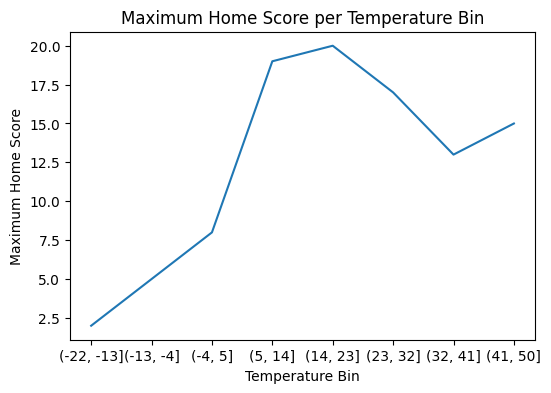

In [ ]:
# Create bins for temperature
df['temperature_bin'] = pd.cut(df['max_temp_c'], bins=range(int(df['max_temp_c'].min()), int(df['max_temp_c'].max()) + 9, 9))

# Group by temperature bin and get the maximum home score for each bin
max_home_scores_per_bin = df.groupby('temperature_bin')['home_score'].max()

# Create the line plot
plt.figure(figsize=(6, 4))
plt.plot(max_home_scores_per_bin.index.astype(str), max_home_scores_per_bin.values)
plt.xlabel('Temperature Bin')
plt.ylabel('Maximum Home Score')
plt.title('Maximum Home Score per Temperature Bin')
plt.show()

<ipython-input-94-4d0918230f21>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_home_scores_per_bin = df.groupby('temperature_bin')['away_score'].max()


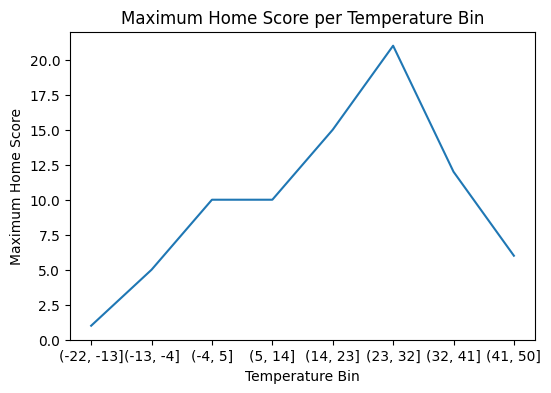

In [ ]:
# Group by temperature bin and get the maximum home score for each bin
max_home_scores_per_bin = df.groupby('temperature_bin')['away_score'].max()

# Create the line plot
plt.figure(figsize=(6, 4))
plt.plot(max_home_scores_per_bin.index.astype(str), max_home_scores_per_bin.values)
plt.xlabel('Temperature Bin')
plt.ylabel('Maximum Home Score')
plt.title('Maximum Home Score per Temperature Bin')
plt.show()

**Narrative**. Our detailed analysis of the difference of both home_score and away_score depending on climatic conditions (cold as defined by < 10 degress C) and warm (>= 10 degrees C) has revealed a significant difference. The graphs show the discovered trend, where on lower temperatures, the maximum number of goals achieved in any game is much lower than at higher temperatures.  

# Possible actions based on results (Act)



> *Provide a brief description of possible actions to be derived from your data-based insights.*



Training plans could be adapted to better prepare players for cold weather conditions especially if upcoming tournaments are in the Cold climate zone.

# Final Reflection



> *Briefly reflect on possible issues or limitations with respect to data ethics and data privacy/security. Structure as illustrated below, i.e., one sub-section for each aspect.*



## Considerations on data ethics

Given the available data, the results only apply to professional national teams, already benefiting from comprehensive measures for top-performance. Non-professional / more local teams are not considered, while they may potentially benefit most from this type of study.

We did not keep track of metadata giving credit / showing attribution to the different sources and dataset authors. If we decided to publish the derived dataset or notebook, we would neet to make sure proper attribution is given and ensure data use is compliant with licences.

## Considerations on data privacy and security

Being purely based on open data without any personal information, there are no special risks or measures to be taken to ensure data privacy or security when considering a data science deployment.